In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prachijakati/personal-expense-dataset/personal_expense_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/prachijakati/personal-expense-dataset/personal_expense_dataset.csv')

print(df.head())

print(df.info())

     UserID  Year  Month   Income  Income_Bracket       Festivals  \
0  USER_012  2021      1  7268.67               4  New Year's Day   
1  USER_014  2021      1  5017.75               3  New Year's Day   
2  USER_020  2021      1  2646.92               1  New Year's Day   
3  USER_023  2021      1  8131.00               4  New Year's Day   
4  USER_039  2021      1  7702.83               4  New Year's Day   

   Festival_Count    Food  Groceries  Transport  ...  Savings  Food_Ratio  \
0               1  551.13     879.47     633.01  ...   605.61      0.0758   
1               1  446.65     683.99     502.62  ...    -1.66      0.0890   
2               1  241.63     399.62     237.00  ...    12.50      0.0913   
3               1  646.30    1055.70     761.08  ...   598.61      0.0795   
4               1  665.16     895.81     779.55  ...   -18.64      0.0864   

   Groceries_Ratio  Transport_Ratio  Entertainment_Ratio  Shopping_Ratio  \
0           0.1210           0.0871           

In [3]:
import pandas as pd
import numpy as np

# 1. عدد القيم المفقودة
print("--- القيم المفقودة لكل عمود ---")
print(df.isnull().sum())

# 2. نوع كل عمود
print("\n--- أنواع البيانات لكل عمود ---")
print(df.dtypes)

# 3. حساب القيم المتطرفة (Outliers) بالأرقام
# سنستخدم طريقة IQR (Interquartile Range) وهي الأدق
print("\n--- عدد القيم المتطرفة (Outliers) لكل عمود رقمي ---")
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

--- القيم المفقودة لكل عمود ---
UserID                 0
Year                   0
Month                  0
Income                 0
Income_Bracket         0
Festivals              0
Festival_Count         0
Food                   0
Groceries              0
Transport              0
Entertainment          0
Shopping               0
Rent                   0
Bills                  0
Healthcare             0
Education              0
Total_Expenses         0
Savings                0
Food_Ratio             0
Groceries_Ratio        0
Transport_Ratio        0
Entertainment_Ratio    0
Shopping_Ratio         0
Rent_Ratio             0
Bills_Ratio            0
Healthcare_Ratio       0
Education_Ratio        0
dtype: int64

--- أنواع البيانات لكل عمود ---
UserID                  object
Year                     int64
Month                    int64
Income                 float64
Income_Bracket           int64
Festivals               object
Festival_Count           int64
Food                   float64

In [7]:
"""
==================================================================
موديل تعلم آلي للتنبؤ بإجمالي المصاريف الشهرية (Total_Expenses)
==================================================================
الفكرة الأساسية: نريد نظام تنبؤي "استباقي" — أي يتنبأ بالمصاريف
المتوقعة في بداية الشهر اعتماداً على بيانات معروفة مسبقاً (الدخل،
الشهر، المهرجانات...) وليس اعتماداً على بنود الصرف نفسها أو النسب
المشتقة منها (لأن هذه بيانات "بعد الحدث" وتسبب Data Leakage).
==================================================================
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ------------------------------------------------------------------
# 1) تحميل البيانات
# ------------------------------------------------------------------
# مسار الملف على Kaggle
df = pd.read_csv("/kaggle/input/datasets/prachijakati/personal-expense-dataset/personal_expense_dataset.csv")

print("شكل البيانات:", df.shape)
print(df.head())

# ------------------------------------------------------------------
# 2) Feature Selection: استبعاد أعمدة الـ Leakage
# ------------------------------------------------------------------
# السبب: أي عمود مشتق من بنود الصرف (Food, Rent, Bills, ...) أو من
# النسب (Food_Ratio, Rent_Ratio, ...) أو Savings هو في الحقيقة نتيجة
# لعملية الصرف نفسها (Total_Expenses = مجموع هذه البنود، والنسب =
# البند / الإجمالي). فلو تركناها في X فإن الموديل سيتعلم "يحسب"
# الإجمالي بدل أن "يتنبأ" به، وهذا يعطي دقة عالية جداً في الاختبار
# لكنه عديم الفائدة عملياً لأن هذه البيانات غير متاحة في بداية الشهر.

leakage_cols = [
    "Food", "Groceries", "Transport", "Entertainment", "Shopping",
    "Rent", "Bills", "Healthcare", "Education",   # بنود الصرف التفصيلية
    "Food_Ratio", "Groceries_Ratio", "Transport_Ratio",
    "Entertainment_Ratio", "Shopping_Ratio", "Rent_Ratio",
    "Bills_Ratio", "Healthcare_Ratio", "Education_Ratio",  # النسب
    "Savings",  # المدخرات (نتيجة أيضاً: Income - Total_Expenses)
]

target_col = "Total_Expenses"

# الأعمدة المتبقية بعد الاستبعاد هي فقط العوامل "السابقة" لعملية الصرف
feature_cols = [c for c in df.columns if c not in leakage_cols + [target_col, "UserID"]]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("\nالأعمدة المستخدمة كمدخلات (Features):")
print(feature_cols)

# ------------------------------------------------------------------
# 3) تحديد الأعمدة الرقمية والفئوية لتطبيق المعالجة المناسبة لكل نوع
# ------------------------------------------------------------------
categorical_cols = ["Festivals"]  # يحتاج One-Hot Encoding
numerical_cols = [c for c in feature_cols if c not in categorical_cols]
# مثال: Year, Month, Income, Income_Bracket, Festival_Count

# ------------------------------------------------------------------
# 4) بناء Preprocessing Pipeline: Encoding + Scaling
# ------------------------------------------------------------------
# - OneHotEncoder لعمود Festivals: لأنه عمود نصي (فئوي) غير مرتب،
#   ولا يجوز تحويله لأرقام عادية لأن ذلك يوهم الموديل بوجود ترتيب
#   بين المهرجانات وهو غير صحيح.
# - RobustScaler للأعمدة الرقمية: لأنه يعتمد على الوسيط (Median)
#   والمدى الربيعي (IQR) بدل المتوسط والانحراف المعياري، وهذا يجعله
#   أقل تأثراً بالـ Outliers الموجودة في الدخل والمصاريف مقارنة
#   بـ StandardScaler العادي.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# ------------------------------------------------------------------
# 5) تقسيم البيانات إلى Train / Test (80% / 20%)
# ------------------------------------------------------------------
# نستخدم random_state ثابت لضمان إمكانية إعادة إنتاج نفس النتائج
# عند إعادة تشغيل الكود (Reproducibility).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nحجم بيانات التدريب: {X_train.shape[0]} صف")
print(f"حجم بيانات الاختبار: {X_test.shape[0]} صف")

# ------------------------------------------------------------------
# 6) بناء الموديل: GradientBoostingRegressor داخل Pipeline كامل
# ------------------------------------------------------------------
# دمج المعالجة المسبقة (preprocessor) مع الموديل في Pipeline واحد
# يضمن عدم تسرب معلومات من بيانات الاختبار أثناء التدريب (Data
# Leakage من نوع آخر يخص الـ Scaling نفسه)، لأن fit تتم فقط على
# بيانات التدريب ثم transform على الاختبار.

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

# ------------------------------------------------------------------
# 7) ضبط المعايير (Hyperparameter Tuning) باستخدام GridSearchCV
# ------------------------------------------------------------------
# الهدف من ضبط هذه المعايير تحديداً هو منع الـ Overfitting:
# - n_estimators: عدد الأشجار (كثرتها بدون ضبط باقي المعايير تسبب حفظ للبيانات)
# - learning_rate: معدل تعلم منخفض مع عدد أشجار أكبر = تعميم أفضل
# - max_depth: أشجار ضحلة (3-5) تمنع الموديل من حفظ تفاصيل دقيقة جداً
# - subsample: أخذ عينة عشوائية من بيانات التدريب لكل شجرة (Stochastic
#   Gradient Boosting) يقلل التباين ويحسن التعميم
# - min_samples_leaf: يمنع إنشاء أوراق (leaves) تحتوي على عدد قليل
#   جداً من العينات، وهو ما قد يمثل حفظاً لحالات فردية (Noise)

param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
    "regressor__max_depth": [3, 4, 5],
    "regressor__subsample": [0.8, 1.0],
    "regressor__min_samples_leaf": [5, 10, 20],
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,                      # 5-Fold Cross Validation لتقييم أكثر ثباتاً
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("\nأفضل معايير (Hyperparameters):")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# ------------------------------------------------------------------
# 8) التقييم: MAE و R2 Score على بيانات التدريب والاختبار
# ------------------------------------------------------------------
# نقارن أداء الموديل على Train و Test معاً:
# - إذا كان الأداء ممتازاً على Train وضعيفاً جداً على Test => Overfitting
# - MAE يعطينا فكرة واقعية عن متوسط الخطأ بالجنيه/الدولار (سهل الفهم)
# - R2 Score يعطينا فكرة عن نسبة التباين في المصاريف التي يفسرها الموديل

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n================ نتائج التقييم ================")
print(f"Train MAE : {train_mae:.2f}")
print(f"Test  MAE : {test_mae:.2f}")
print(f"Train R2  : {train_r2:.4f}")
print(f"Test  R2  : {test_r2:.4f}")
print("=================================================")

# ملاحظة: فرق كبير بين Train و Test (مثلاً R2 تدريب 0.98 مقابل
# R2 اختبار 0.60) يعني أن الموديل ما زال يحفظ البيانات، وهنا يجب
# تقليل max_depth أو زيادة min_samples_leaf أو تقليل learning_rate.

# ------------------------------------------------------------------
# 9) (اختياري) أهمية المتغيرات Feature Importance
# ------------------------------------------------------------------
# يساعد على فهم أي العوامل (الدخل، الشهر، المهرجانات...) لها التأثير
# الأكبر على توقع المصاريف، وهذا مفيد لتفسير الموديل للمستخدم النهائي.

feature_names = (
    numerical_cols +
    list(best_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_cols))
)

importances = best_model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\nأهمية المتغيرات (Feature Importance):")
print(importance_df.to_string(index=False))

شكل البيانات: (3655, 27)
     UserID  Year  Month   Income  Income_Bracket       Festivals  \
0  USER_012  2021      1  7268.67               4  New Year's Day   
1  USER_014  2021      1  5017.75               3  New Year's Day   
2  USER_020  2021      1  2646.92               1  New Year's Day   
3  USER_023  2021      1  8131.00               4  New Year's Day   
4  USER_039  2021      1  7702.83               4  New Year's Day   

   Festival_Count    Food  Groceries  Transport  ...  Savings  Food_Ratio  \
0               1  551.13     879.47     633.01  ...   605.61      0.0758   
1               1  446.65     683.99     502.62  ...    -1.66      0.0890   
2               1  241.63     399.62     237.00  ...    12.50      0.0913   
3               1  646.30    1055.70     761.08  ...   598.61      0.0795   
4               1  665.16     895.81     779.55  ...   -18.64      0.0864   

   Groceries_Ratio  Transport_Ratio  Entertainment_Ratio  Shopping_Ratio  \
0           0.1210   

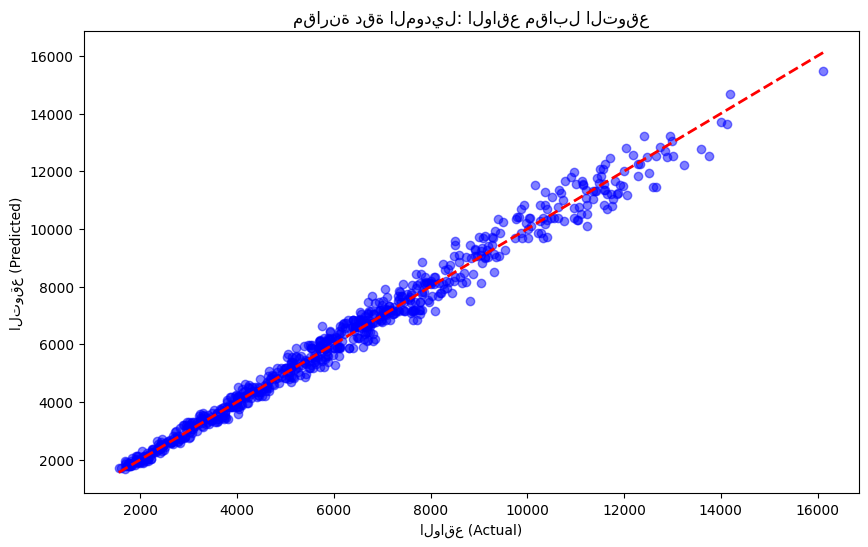

/tmp/ipykernel_58/3467806793.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


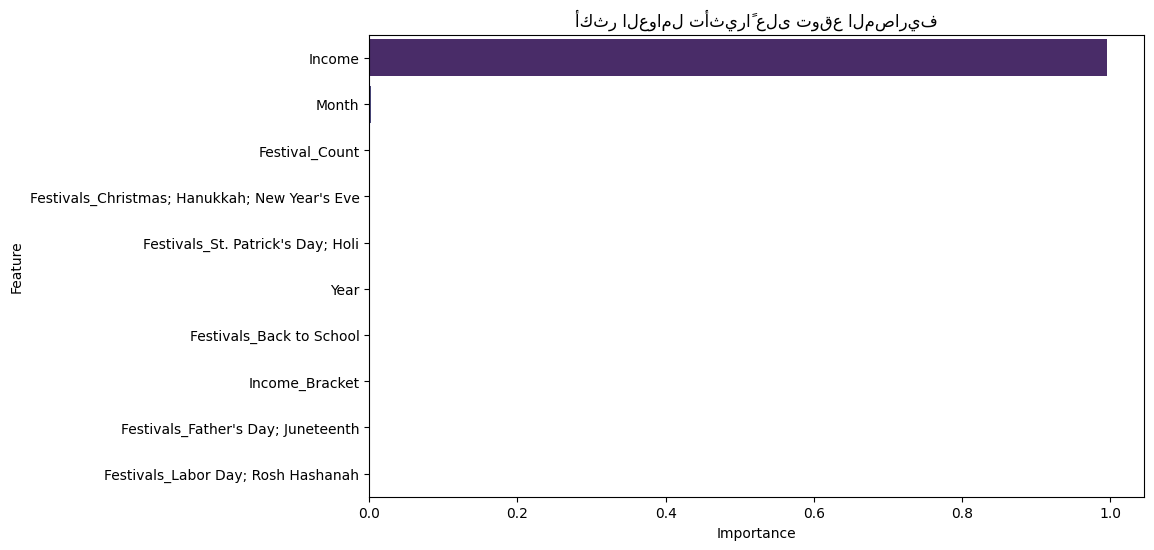

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. رسم بياني للمقارنة بين الواقع والتوقع (Actual vs Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('الواقع (Actual)')
plt.ylabel('التوقع (Predicted)')
plt.title('مقارنة دقة الموديل: الواقع مقابل التوقع')
plt.show()

# 2. رسم بياني لأهمية المتغيرات (Feature Importance)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('أكثر العوامل تأثيراً على توقع المصاريف')
plt.show()

In [10]:
"""
==================================================================
تحسينات إضافية مقترحة على الموديل الأساسي
==================================================================
"""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# افترض أن best_model, X_train, X_test, y_train, y_test, preprocessor
# موجودين بالفعل من الكود السابق

# ------------------------------------------------------------------
# تحسين 1: MAPE بدل الاعتماد على MAE وحده
# ------------------------------------------------------------------
# MAE = 261 قد يبدو كبير أو صغير حسب حجم الأرقام نفسها. الأفضل نعرف
# نسبة الخطأ من متوسط قيمة Total_Expenses لفهم الحجم الحقيقي للخطأ.

y_test_pred = best_model.predict(X_test)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
mean_expense = y_test.mean()

print(f"متوسط Total_Expenses في بيانات الاختبار: {mean_expense:.2f}")
print(f"MAPE (نسبة الخطأ المئوية): {mape:.2f}%")
print(f"MAE كنسبة من المتوسط: {(261.60/mean_expense)*100:.2f}%")

# ------------------------------------------------------------------
# تحسين 2: مقارنة بموديل بسيط (Linear Regression) كـ Baseline
# ------------------------------------------------------------------
# لو موديل خطي بسيط بيدّي نفس النتيجة تقريباً، فده معناه إن العلاقة
# شبه خطية (Income وحده كافي)، وإن GradientBoosting مش بيضيف قيمة
# حقيقية غير التعقيد الزائد. لو الفرق كبير لصالح GBM، يبقى فيه علاقات
# غير خطية فعلاً استفاد منها الموديل.

from sklearn.pipeline import Pipeline
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
lr_pred = linear_pipeline.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score
print(f"\nLinear Regression - Test MAE: {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"Linear Regression - Test R2 : {r2_score(y_test, lr_pred):.4f}")
print("(قارن هذا بنتائج GradientBoosting: MAE=261.60, R2=0.9858)")

# ------------------------------------------------------------------
# تحسين 3: Cross-Validation على كامل بيانات التدريب (وليس Split واحد)
# ------------------------------------------------------------------
# تقييم أكثر ثباتاً بدل الاعتماد على تقسيم واحد فقط للـ Test

cv_scores = cross_val_score(
    best_model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error"
)
print(f"\nMAE عبر 5-Fold CV: {-cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

# ------------------------------------------------------------------
# تحسين 4: تحليل الأخطاء الأكبر (Residual Analysis)
# ------------------------------------------------------------------
# نشوف هل الموديل بيخطئ أكتر عند دخل معين أو شهر معين، وده ممكن
# يوجّهنا لإضافة Feature Engineering (مثلاً Income * Festival_Count)

residuals = y_test - y_test_pred
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = y_test_pred
error_df["Abs_Error"] = np.abs(residuals.values)

print("\nأكبر 10 حالات خطأ (يستحق مراجعتها):")
print(error_df.sort_values("Abs_Error", ascending=False).head(10)
      [["Income", "Month", "Festivals", "Actual", "Predicted", "Abs_Error"]])

# ------------------------------------------------------------------
# تحسين 5 (اختياري): Feature Engineering - تفاعل بين الدخل والشهر/المهرجان
# ------------------------------------------------------------------
# ممكن تضيف عمود جديد قبل التدريب:
# X["Income_x_FestivalCount"] = X["Income"] * X["Festival_Count"]
# ده ممكن يساعد الموديل يلتقط إن تأثير المهرجانات بيكبر مع زيادة الدخل

متوسط Total_Expenses في بيانات الاختبار: 6132.10
MAPE (نسبة الخطأ المئوية): 4.31%
MAE كنسبة من المتوسط: 4.27%

Linear Regression - Test MAE: 269.58
Linear Regression - Test R2 : 0.9851
(قارن هذا بنتائج GradientBoosting: MAE=261.60, R2=0.9858)

MAE عبر 5-Fold CV: 247.93 (+/- 3.02)

أكبر 10 حالات خطأ (يستحق مراجعتها):
        Income  Month                            Festivals    Actual  \
557   12254.17      8                       Back to School  10163.84   
596    7969.17      8                       Back to School   8819.03   
2659  12809.81     11           Thanksgiving; Veterans Day  13764.40   
166   12891.02      3              St. Patrick's Day; Holi  12667.85   
432   12338.20      6             Father's Day; Juneteenth  12595.06   
343   10870.42      5           Mother's Day; Memorial Day  11236.55   
2893  10046.95      2    Valentine's Day; Chinese New Year   8513.12   
897    8767.36     12  Christmas; Hanukkah; New Year's Eve   7813.18   
2656  12914.54     11           Th

In [11]:
"""
==================================================================
حفظ الموديل النهائي واستخدامه للتنبؤ (Deployment)
==================================================================
"""

import joblib
import pandas as pd

# ------------------------------------------------------------------
# 1) حفظ الموديل بعد التدريب (best_model من الكود الأساسي)
# ------------------------------------------------------------------
# نحفظ الـ Pipeline بالكامل (Preprocessing + Model) في ملف واحد
joblib.dump(best_model, "expense_prediction_model.pkl")
print("تم حفظ الموديل بنجاح: expense_prediction_model.pkl")

# ==================================================================
# 2) تحميل الموديل واستخدامه لاحقاً (في تطبيق/API منفصل مثلاً)
# ==================================================================
loaded_model = joblib.load("expense_prediction_model.pkl")

# مثال: بيانات مستخدم جديد في بداية الشهر (نفس أسماء الأعمدة بالضبط)
new_user_data = pd.DataFrame({
    "Year": [2026],
    "Month": [12],
    "Income": [9500.00],
    "Income_Bracket": [4],
    "Festivals": ["Christmas; Hanukkah; New Year's Eve"],
    "Festival_Count": [3],
})

predicted_expense = loaded_model.predict(new_user_data)
print(f"\nالمصاريف المتوقعة للمستخدم: {predicted_expense[0]:.2f}")

تم حفظ الموديل بنجاح: expense_prediction_model.pkl

المصاريف المتوقعة للمستخدم: 9678.71
